# PSFField visualisation

Quick look at what the trained `PSFField` model actually represents.
Renders per-band median PSFs, radial profiles, spatial variation across
the tile, and chromatic blue-vs-red SED-conditioned PSFs at fixed
position.

**SIREN extrapolation note.** SIREN's sine activations can oscillate
outside the training support, so panels are rendered at the training
stamp size (read from the checkpoint config) and axes are clipped to
the training extent. This avoids extrapolation artefacts that would
otherwise appear in the wings.

Sections:

1. Per-band median PSF at tile centre with mean-SED conditioning.
2. Per-band radial profile inside the training extent.
3. Spatial variation -- Rubin r-band across a 3x3 grid of tile positions.
4. Chromatic PSF -- blue-SED vs red-SED in the VIS band.

Checkpoint: `models/checkpoints/psf_field_v3.pt` (current production:
SIREN + SED + DCR + per-band radial envelope).


In [8]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'io' else Path.cwd()
sys.path.insert(0, str(ROOT / 'models'))

from psf.psf_field import (
    PSFField, BAND_ORDER, BAND_PX_SCALE, N_BANDS,
    normalise_psf,
)

CHECKPOINT = ROOT / 'models/checkpoints/psf_field_v3.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, ' checkpoint:', CHECKPOINT.exists())

device: cuda  checkpoint: True


In [9]:
# Load checkpoint + rebuild the SIREN with matching architecture.
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
cfg = ckpt['config']
psf = PSFField(
    sed_embed_dim=cfg['sed_embed_dim'],
    band_embed_dim=cfg['band_embed_dim'],
    tile_freqs=cfg['tile_freqs'],
    siren_hidden=cfg['siren_hidden'],
    siren_depth=cfg['siren_depth'],
    w0_first=cfg['w0_first'],
    envelope_r_rubin=cfg.get('envelope_r_rubin', 0.0),
    envelope_r_euclid=cfg.get('envelope_r_euclid', 0.0),
    envelope_power=cfg.get('envelope_power', 4.0),
).to(device).eval()
psf.load_state_dict(ckpt['psf_field_state'])

# Training stamp size → determines per-band angular support we can trust.
TRAIN_STAMP = cfg['stamp_size']
TRAIN_HALF_ARCSEC = ((TRAIN_STAMP - 1) / 2.0) * BAND_PX_SCALE.numpy()
env_r_rubin = cfg.get('envelope_r_rubin', 0.0)
env_r_euclid = cfg.get('envelope_r_euclid', 0.0)
print(f"epoch={ckpt.get('epoch')}  siren={cfg['siren_hidden']}x{cfg['siren_depth']}  "
      f"stamp_size={TRAIN_STAMP}  w0={cfg['w0_first']}")
print(f"envelope r_core (arcsec): Rubin={env_r_rubin}, Euclid={env_r_euclid}")
print(f"training extent per band (± arcsec): Rubin={TRAIN_HALF_ARCSEC[0]:.2f}, Euclid={TRAIN_HALF_ARCSEC[6]:.2f}")

epoch=59  siren=192x6  stamp_size=25  w0=15.0
envelope r_core (arcsec): Rubin=1.7, Euclid=0.85
training extent per band (± arcsec): Rubin=2.40, Euclid=1.20


In [10]:
@torch.no_grad()
def render(band_idx, tile_xy=(0.5, 0.5), sed=None, stamp_size=None, sub_grid=6):
    """Normalised PSF stamp at training-supported extent."""
    if stamp_size is None:
        stamp_size = TRAIN_STAMP
    tp = torch.tensor([tile_xy], device=device, dtype=torch.float32)
    if sed is None:
        sed = torch.zeros(1, N_BANDS, device=device)
    stamp = psf.render_stamps(
        centroids_arcsec=torch.zeros(1, 2, device=device),
        tile_pos=tp,
        band_idx=torch.tensor([band_idx], device=device, dtype=torch.long),
        sed_vec=sed,
        stamp_size=stamp_size,
        px_scale=float(BAND_PX_SCALE[band_idx]),
        sub_grid=sub_grid,
        apply_dcr=False,
    )[0]
    return normalise_psf(stamp, float(BAND_PX_SCALE[band_idx])).cpu().numpy()

## 1. Median PSF per band (linear, clipped at 2% of peak)

Linear scale with a light ceiling — emphasises the core without letting the noisy far-field dominate the color map. Each panel uses its own native pixel scale but is displayed on matched ±1.2" axes so physical sizes compare correctly.

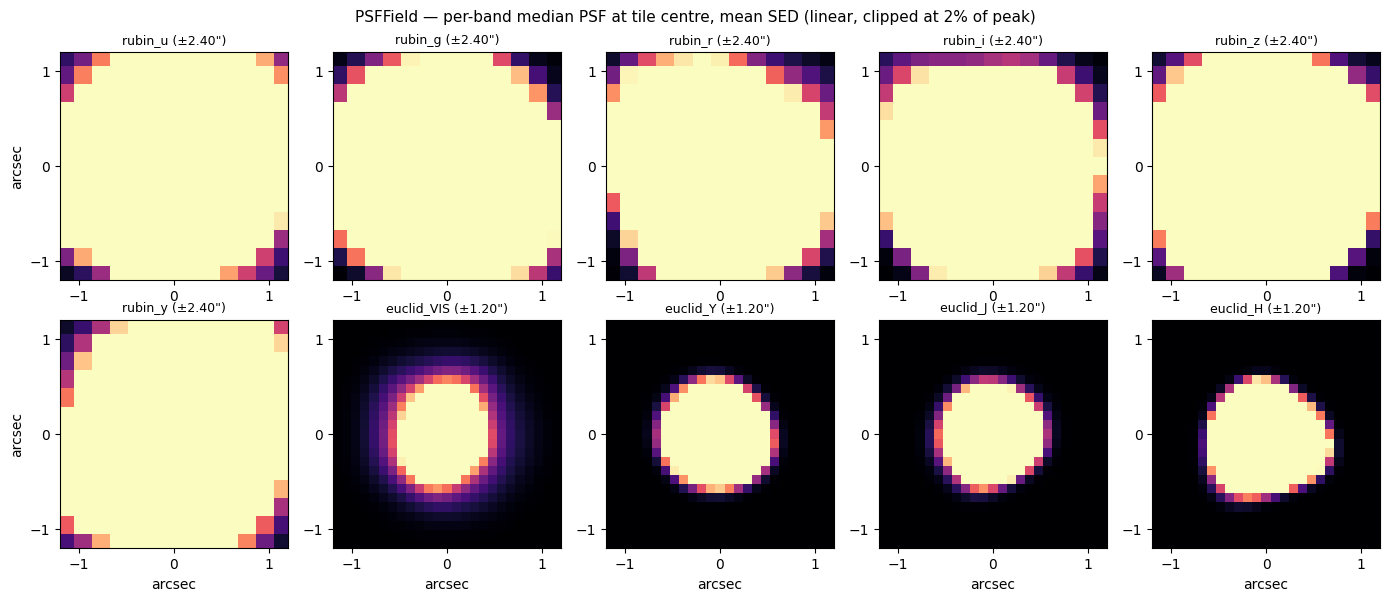

In [11]:
DISPLAY_HALF = 1.2   # arcsec axis half-extent for visual comparison

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for bi, (band, ax) in enumerate(zip(BAND_ORDER, axes.flat)):
    p = render(bi)                       # rendered at training stamp size
    ext = float(TRAIN_HALF_ARCSEC[bi])   # per-band training extent
    # Clip visual ceiling at 2% of peak → core dominates colourmap
    vmax = 0.02 * p.max()
    ax.imshow(p, origin='lower', cmap='magma',
              extent=[-ext, ext, -ext, ext],
              vmin=0, vmax=vmax, interpolation='nearest')
    ax.set_title(f'{band} (±{ext:.2f}")', fontsize=9)
    ax.set_xlim(-DISPLAY_HALF, DISPLAY_HALF)
    ax.set_ylim(-DISPLAY_HALF, DISPLAY_HALF)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
    if bi % 5 == 0: ax.set_ylabel('arcsec')
    if bi >= 5:     ax.set_xlabel('arcsec')
fig.suptitle('PSFField — per-band median PSF at tile centre, mean SED (linear, clipped at 2% of peak)', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Radial profiles — inside training extent only

Azimuthal mean, log-y to see wings. **X-axis is clipped per band to the training extent** — rendering beyond this is SIREN extrapolation and not physically meaningful.

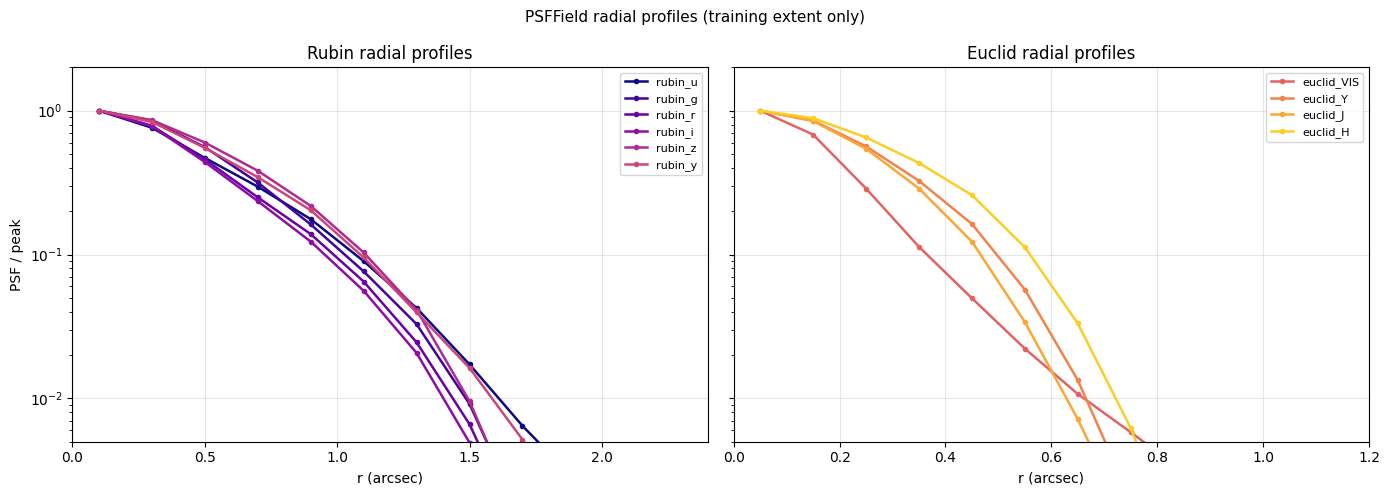

In [12]:
def radial_profile(stamp, px_scale, n_bins=None):
    """Azimuthal mean, skipping empty bins.

    Default `n_bins = (stamp_size - 1) / 2` so every bin contains at least
    one pixel ring — otherwise alternating bins are empty and a log-y plot
    shows aliasing spikes that are artefacts of the histogram, not the PSF.
    """
    S = stamp.shape[-1]
    half = (S - 1) / 2.0
    if n_bins is None:
        n_bins = max(4, int(half))
    y, x = np.mgrid[:S, :S]
    r_arc = np.sqrt((x - half)**2 + (y - half)**2) * px_scale
    r_max = half * px_scale
    edges = np.linspace(0, r_max, n_bins + 1)
    idx = np.clip(np.digitize(r_arc.ravel(), edges) - 1, 0, n_bins - 1)
    centres, means = [], []
    for k in range(n_bins):
        mask = idx == k
        if mask.any():
            centres.append(0.5 * (edges[k] + edges[k + 1]))
            means.append(stamp.ravel()[mask].mean())
    r = np.array(centres); prof = np.array(means)
    return r, prof / prof.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.plasma(np.linspace(0, 0.9, N_BANDS))
for bi, band in enumerate(BAND_ORDER):
    p = render(bi)
    r, prof = radial_profile(p, float(BAND_PX_SCALE[bi]))
    keep = r <= TRAIN_HALF_ARCSEC[bi]
    is_rubin = band.startswith('rubin')
    ax = axes[0 if is_rubin else 1]
    ax.plot(r[keep], prof[keep], color=colors[bi], lw=1.8,
            marker='o', markersize=3, label=band)
for ax, title in zip(axes, ['Rubin', 'Euclid']):
    ax.set_yscale('log')
    ax.set_xlim(0, TRAIN_HALF_ARCSEC[0] if title == 'Rubin' else TRAIN_HALF_ARCSEC[6])
    ax.set_ylim(5e-3, 2)
    ax.set_xlabel('r (arcsec)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(f'{title} radial profiles')
axes[0].set_ylabel('PSF / peak')
fig.suptitle('PSFField radial profiles (training extent only)', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Spatial variation — Rubin r-band across the tile

3×3 grid of tile positions. Each panel has its own vmax. If the spatial conditioning is doing something, we should see subtle shape / ellipticity changes across positions.

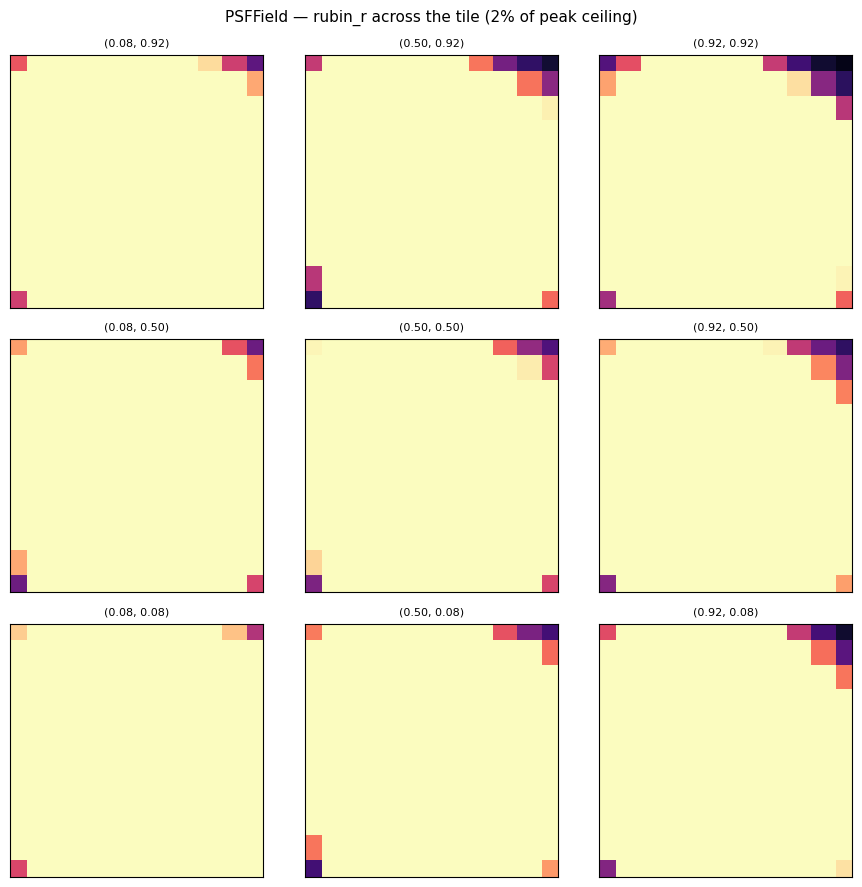

In [13]:
SHOW_BAND = 'rubin_r'
bi = BAND_ORDER.index(SHOW_BAND)
ext = float(TRAIN_HALF_ARCSEC[bi])
coords = [0.08, 0.5, 0.92]

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, y_t in enumerate(coords):
    for j, x_t in enumerate(coords):
        p = render(bi, tile_xy=(x_t, y_t))
        ax = axes[2 - i, j]   # bottom-row = low y
        ax.imshow(p, origin='lower', cmap='magma',
                  extent=[-ext, ext, -ext, ext],
                  vmin=0, vmax=0.02 * p.max(), interpolation='nearest')
        ax.set_title(f'({x_t:.2f}, {y_t:.2f})', fontsize=8)
        ax.set_xlim(-1.0, 1.0); ax.set_ylim(-1.0, 1.0)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'PSFField — {SHOW_BAND} across the tile (2% of peak ceiling)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Chromatic PSF — VIS for blue vs red stars

Same band (Euclid VIS), same tile position, different SED. A hot blue star should have a slightly sharper VIS PSF than a cool red star, because the filter passes a range of wavelengths and PSF width scales with λ.

We feed in an artificial SED that has extra flux at the blue end (Rubin u/g) vs the red end (Euclid J/H).

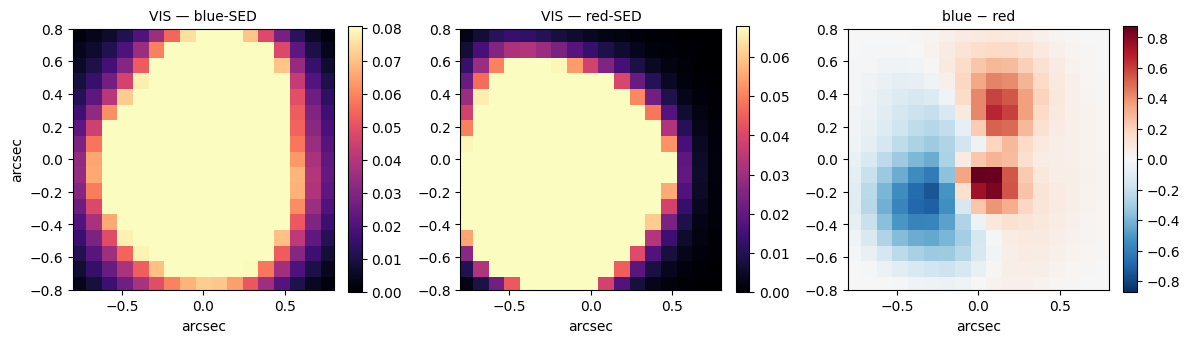

Blue-SED VIS FWHM: 0.3909"
Red-SED  VIS FWHM: 0.4222"


In [14]:
bi = BAND_ORDER.index('euclid_VIS')
px = float(BAND_PX_SCALE[bi])
ext = float(TRAIN_HALF_ARCSEC[bi])

def sed_for(bluer: bool) -> torch.Tensor:
    v = torch.zeros(1, N_BANDS, device=device)
    sign = +1.0 if bluer else -1.0
    v[0, BAND_ORDER.index('rubin_u')] = +1.2 * sign
    v[0, BAND_ORDER.index('rubin_g')] = +0.7 * sign
    v[0, BAND_ORDER.index('rubin_r')] = +0.2 * sign
    v[0, BAND_ORDER.index('euclid_VIS')] = 0.0
    v[0, BAND_ORDER.index('euclid_J')] = -0.7 * sign
    v[0, BAND_ORDER.index('euclid_H')] = -1.2 * sign
    return v - v.mean(dim=-1, keepdim=True)

p_blue = render(bi, sed=sed_for(bluer=True))
p_red  = render(bi, sed=sed_for(bluer=False))
diff = p_blue - p_red

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title, cmap in (
    (axes[0], p_blue, 'VIS — blue-SED', 'magma'),
    (axes[1], p_red,  'VIS — red-SED',  'magma'),
    (axes[2], diff,   'blue − red',      'RdBu_r'),
):
    if cmap == 'RdBu_r':
        vmax = float(max(abs(img.min()), abs(img.max())))
        vmin = -vmax
    else:
        vmax = 0.02 * img.max()
        vmin = 0
    im = ax.imshow(img, origin='lower', cmap=cmap,
                   extent=[-ext, ext, -ext, ext],
                   vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.8, 0.8); ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('arcsec')
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel('arcsec')
plt.tight_layout()
plt.show()

def fwhm_px(stamp):
    peak = stamp.max()
    area = (stamp >= 0.5 * peak).sum()
    return 2.0 * (area / np.pi) ** 0.5
print(f'Blue-SED VIS FWHM: {fwhm_px(p_blue) * px:.4f}"')
print(f'Red-SED  VIS FWHM: {fwhm_px(p_red)  * px:.4f}"')